# This tutorial presents the code used to generate some of the figures publihsed in the article entitled 'Fast Fourier Transform-Based Distribution of Relaxation Times Analysis for Efficient and Flexible Time-Domain Electrochemical Impedance Characterization' (DOI: 10.1149/1945-7111/adb33f).

In [1]:
# import the necessary modules
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import cvxpy as cp
import pyDRT
import os
import time
from bayes_opt import BayesianOptimization
from functools import partial
from scipy import signal
import pickle

In [2]:
# Font setup for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

In [3]:
# define the necessary functions

# function to compute P and q for the QP
def compute_P_q_norm(A, v):
    '''
    compute the matrices P and q for the quadratic programming problem

    parameters:
    A (ndarray): matrix A from the equation A x = u
    v (ndarray): exp voltage measurements vector

    returns:
    P (ndarray): matrix P in the quadratic term of the objective
    q (ndarray): vector q in the linear term of the objective
    '''
    P = A.T @ A
    q = -A.T @ v
    return P, q

# function to solve the optimization problem
def compute_gamma(lambda_reg, P, q, K, N_x):
    '''
    Solve the optimization problem to estimate R_inf and gamma_hat.

    Parameters:
    lambda_reg (float): Regularization parameter lambda.
    P_np (ndarray): Matrix P from the QP.
    q_np (ndarray): Vector q from the QP.
    K (ndarray): Regularization matrix.

    Returns:
    R_infty (float): Estimated R_inf value.
    gamma_hat (ndarray): Estimated gamma values.
    x_val (ndarray): Solution vector including R_inf and gamma_hat.
    '''
    # Regularization term
    P_reg = P + lambda_reg * K

    # Ensure P_reg is symmetric
    P_reg = 0.5 * (P_reg + P_reg.T)

    # Set up the problem in CVXPY
    x = cp.Variable(N_x)
    # Use cp.psd_wrap to ensure P_reg is recognized as positive semi-definite
    objective = 0.5 * cp.quad_form(x, cp.psd_wrap(P_reg)) + q.T @ x
    constraints = [x >= 0]
    prob = cp.Problem(cp.Minimize(objective), constraints)

    # Solve the problem using MOSEK solver for efficiency
    try:
        prob.solve(solver=cp.MOSEK)
    except cp.error.SolverError:
        # If MOSEK fails, try SCS solver as a fallback
        print('MOSEK failed. Switching to SCS solver.')
        prob.solve(solver=cp.SCS, eps=1e-5)
    if x.value is None:
        raise ValueError('Optimization did not converge')

    x_val = x.value
    R_infty = x_val[0]
    gamma_hat = x_val[1:]
    return R_infty, gamma_hat, x_val

# Define the general objective function
def objective_function(log10_lambda_reg, log10_sigma_aristo, log10_alpha, P, q, gamma_exact, N_x):
    """
    General objective function for Bayesian optimization.

    Parameters:
    log10_lambda_reg (float): Base-10 logarithm of lambda_reg.
    log10_sigma_aristo (float): Base-10 logarithm of sigma_aristo.
    log10_alpha (float): Base-10 logarithm of alpha.
    P_np (ndarray): P matrix for the problem (time or FFT).
    q_np (ndarray): q vector for the problem (time or FFT).

    Returns:
    negative_log10_error_norm (float): Negative of the log10 error norm between gamma_hat and gamma_exact.
    """
    # Exponentiate the parameters to get them back to linear scale
    lambda_reg = 10 ** log10_lambda_reg
    sigma_aristo = 10 ** log10_sigma_aristo
    alpha = 10 ** log10_alpha

    # Recompute L2, L, and K
    L2 = pyDRT.compute_L2_aristo(tau_vec, sigma_aristo)
    L = np.zeros((L2.shape[0], L2.shape[1] + 1))
    L[:, 1:] = L2
    K = L.T @ L
    K[0, 0] = alpha

    # Compute gamma_hat
    try:
        R_infty_est, gamma_hat, x_hat = compute_gamma(lambda_reg, P, q, K, N_x)
    except Exception as e:
        # Optimization did not converge or other error
        print(f'Optimization failed with error: {e}')
        return -np.inf  # Return negative infinity so optimizer avoids this region

    # Compute error norm
    error_norm = np.linalg.norm(gamma_hat - gamma_exact)

    # Check if error_norm is valid
    if error_norm <= 0 or not np.isfinite(error_norm):
        return -np.inf

    log10_error_norm = np.log10(error_norm)

    # Return negative log10 error norm (since BayesianOptimization maximizes the function)
    return -log10_error_norm

# 1. Generate the artificial data

## 1.1 Define the parameters for the input current

In [4]:
# Experiment parameters
t_max = 100
dt = 2e-4
sigma_n = 0.1
t = np.arange(0, t_max, dt)
N_t = t.size

## 1.2 Define the exact DRT of the piecewise-constant element

In [5]:
# tau
N_tau = 101
tau_min = 1e-3
tau_max = 1e3
tau_vec = np.logspace(np.log10(tau_min), np.log10(tau_max), N_tau)

# Impedance parameters
R_inf = 10
R_ct = 50
tau_1 = 0.01
tau_2 = 0.1

# generate exact Gamma using the provided formula
gamma_exact = (R_ct/np.log(tau_2/tau_1))*(np.heaviside(tau_vec-tau_1, 0.5)-np.heaviside(tau_vec-tau_2, 0.5)) 

## 1.3 Define the logarithmic chirp

In [6]:
# Define minimum and maximum frequencies
freq = np.fft.fftfreq(N_t, d=dt)
N_fp1 = int(N_t/2)
slice_plus = range(1, N_fp1)
freq_plus = freq[slice_plus]
min_freq = np.min(np.abs(freq_plus))
max_freq = np.max(freq_plus)
log_min_freq = np.log10(min_freq)
log_max_freq = np.log10(max_freq)
num_decades = log_max_freq - log_min_freq
N_freq = int(10 * num_decades) + 1
freq_log = np.logspace(log_min_freq, log_max_freq, N_freq)

# Pulse current i(t)
Delta_i_pulse = 0.4
i_t = Delta_i_pulse * signal.chirp(t, f0=min_freq, f1=max_freq, t1=t_max, phi=-90, method='logarithmic')
I_hat = np.fft.fft(i_t)

## 1.4 Define the fast-Fourier-transform (FFT) data and matrices

In [7]:
start_time = time.time()

I_omega = np.fft.fft(i_t)
omega = 2 * np.pi * np.fft.fftfreq(N_t, d=dt)
delta_log_tau = np.log(tau_vec[1]/tau_vec[0])
A_fft_gamma = np.zeros((N_t, N_tau), dtype=complex)

for n in range(N_tau):
    tau_n = tau_vec[n]
    H_n = 1 / (1 + 1j * omega * tau_n)
    A_n_omega = H_n * I_omega
    a_n_t = np.fft.ifft(A_n_omega) * delta_log_tau
    A_fft_gamma[:, n] = a_n_t

v_t_fft = R_inf * i_t + np.real(A_fft_gamma) @ gamma_exact
v_t_fft_exp = v_t_fft + sigma_n * np.random.randn(N_t)
A_fft = np.hstack((i_t[:, np.newaxis], np.real(A_fft_gamma)))

end_time = time.time()
compute_A_fft = end_time - start_time
print(f'Duration of A_fft: {compute_A_fft:.4f} seconds')


P_np_fft, q_np_fft = compute_P_q_norm(A_fft, v_t_fft_exp)

Duration of A_fft: 6.4023 seconds


## 1.5 Plot the input current and output voltage (Figure 1 (b) in the manuscript)

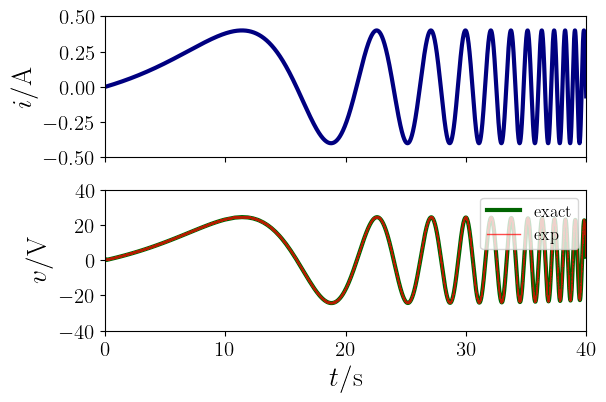

In [8]:
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.44, 6), sharex=True)

# top subplot: plot the input current i(t) over time
ax1.plot(t, i_t, linewidth=3, color='navy')
ax1.set_ylabel(r'$i/\rm A$', fontsize=20)  # label the y-axis with current in amperes
ax1.set_xlim(0, 40)  
ax1.set_ylim(-0.5, 0.5)
ax1.set_yticks(np.arange(-0.5, 0.51, 0.25))

# bottom subplot: plot the exact and noisy experimental voltage v(t)
ax2.plot(t, v_t_fft, label='exact', linewidth=3, color='darkgreen')
ax2.plot(t, v_t_fft_exp, label='exp', linewidth=1, alpha=0.7, color='red')
ax2.set_xlabel(r'$t/\rm s$', fontsize=20)  # label the x-axis with time in seconds
ax2.set_ylabel(r'$v/\rm V$', fontsize=20)  # label the y-axis with voltage in volts
#ax2.set_xlim(0, 0.01) 
ax2.set_ylim(-40, 40)
ax2.set_yticks(np.arange(-40, 40.1, 20))
ax2.legend(frameon=True, fontsize=12, loc='upper right')  # add legend for clarity

# adjust layout for tight spacing and save the figure
plt.tight_layout()
fig=plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

# 2. Deconvolve the DRT from the FFT problem

## 2.1 Solve the FFT problem using Bayesian optimization

In [9]:
pbounds = {'log10_lambda_reg': (-8, 2), 'log10_sigma_aristo': (-5, 3), 'log10_alpha': (-8, 3)}
fft_objective = partial(objective_function, P=P_np_fft, q=q_np_fft, gamma_exact=gamma_exact, N_x=N_tau+1)

optimizer_fft = BayesianOptimization(f=fft_objective, pbounds=pbounds, random_state=1, verbose=2)
optimizer_fft.maximize(init_points=20, n_iter=100)

# Extract optimal parameters for FFT problem
optimal_params_fft = optimizer_fft.max['params']
optimal_lambda_reg_fft = 10 ** optimal_params_fft['log10_lambda_reg']
optimal_sigma_aristo_fft = 10 ** optimal_params_fft['log10_sigma_aristo']
optimal_alpha_fft = 10 ** optimal_params_fft['log10_alpha']

# Recompute L2, L, and K with optimal parameters
L2_opt_fft = pyDRT.compute_L2_aristo(tau_vec, optimal_sigma_aristo_fft)
L_opt_fft = np.zeros((L2_opt_fft.shape[0], L2_opt_fft.shape[1] + 1))
L_opt_fft[:, 1:] = L2_opt_fft
K_opt_fft = L_opt_fft.T @ L_opt_fft
K_opt_fft[0, 0] = optimal_alpha_fft

# Recompute gamma_hat with optimal parameters
R_infty_hat_fft, gamma_hat_fft, x_hat_fft = compute_gamma(optimal_lambda_reg_fft, P_np_fft, q_np_fft, K_opt_fft, N_tau+1)

# Compute minimized error norm
minimized_log10_norm_fft = -optimizer_fft.max['target']
minimized_norm_fft = 10 ** minimized_log10_norm_fft

# Output the results for FFT problem
print('\nBayesian Optimization Results for FFT problem:')
print(f'Optimal lambda_reg: {optimal_lambda_reg_fft:.4e}')
print(f'Optimal sigma_aristo: {optimal_sigma_aristo_fft:.4e}')
print(f'Optimal alpha: {optimal_alpha_fft:.4e}')
print(f'Minimized error norm: {minimized_norm_fft:.4e}')

|   iter    |  target   | log10_... | log10_... | log10_... |
-------------------------------------------------------------
| 1         | -1.274909 | -3.829779 | 0.7625959 | -7.998741 |
| 2         | -1.281383 | -4.976674 | -3.825952 | -6.984275 |
| 3         | -1.175705 | -6.137397 | -2.235514 | -3.635557 |
| 4         | -1.341777 | -2.611832 | -1.646443 | -0.462585 |
| 5         | -1.188913 | -5.955477 | 2.0249394 | -7.698736 |
| 6         | -1.432057 | -1.295324 | -1.661561 | -1.854411 |
| 7         | -1.178112 | -6.596130 | -3.415188 | 0.8081902 |
| 8         | -1.571849 | 1.6826157 | -2.492606 | -0.384451 |
| 9         | -1.469204 | 0.7638915 | 2.1568533 | -7.064513 |
| 10        | -1.364921 | -7.609452 | -3.641356 | 1.6595675 |
| 11        | -1.221883 | -7.016531 | -1.631138 | 2.5367848 |
| 12        | -1.335282 | -2.668347 | 0.5350169 | -4.529328 |
| 13        | -1.435722 | -1.134990 | 1.6770053 | -7.798828 |
| 14        | -1.440028 | -0.498556 | 2.9108887 | 0.2298221 |
| 15    

## 2.2 Plot the exact and recovered DRTs (Figure 1 (h) in the Supplementary Information)

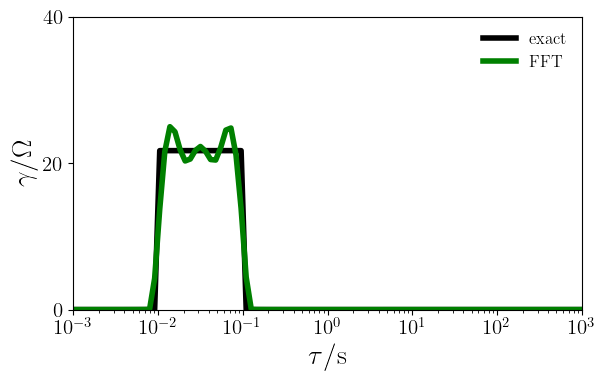

In [10]:
plt.semilogx(tau_vec, gamma_exact, label='exact', linewidth=4, color='black')
plt.semilogx(tau_vec, gamma_hat_fft, label='FFT', linewidth=4, color='green')
plt.xlim(1E-3, 1E3)
plt.ylim(0, 40)
plt.yticks(np.arange(0, 40.1, 20))
plt.xlabel(r'$\tau/{\rm s}$', fontsize=20)
plt.ylabel(r'$\gamma/\Omega$', fontsize=20)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
fig=plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

# 3. Reconstruct the impedance

## 3.1 Reconstruct the impedance from the FFT-based DRT

In [11]:
# Compute A_re_log and A_im_log using freq_log and tau_vec
A_re_log = pyDRT.compute_A_re(freq_log, tau_vec)
A_im_log = pyDRT.compute_A_im(freq_log, tau_vec)
A_R_inf_log = np.zeros((2 * N_freq, 1))
A_R_inf_log[0:N_freq, 0] = 1.0
A_log_stack = np.vstack((A_re_log, A_im_log))
A_log = np.hstack((A_R_inf_log, A_log_stack))
Z_exact_log = R_inf + (R_ct/np.log(tau_2/tau_1))*(np.log(1-1j/(2*pi*freq_log*tau_1))-np.log(1-1j/(2*pi*freq_log*tau_2)))

Z_log_fft_re_im = A_log @ x_hat_fft
Z_log_fft_real = Z_log_fft_re_im[0:N_freq]
Z_log_fft_imag = Z_log_fft_re_im[N_freq:]
Z_log_fft = Z_log_fft_real + 1j * Z_log_fft_imag

## 3.2 Nyquist plots of the exact and FFT impedances (Figure S1 (i) in the Supplementary Information)

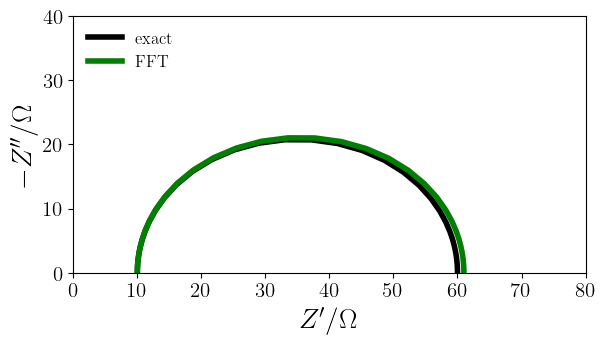

In [12]:
plt.plot(Z_exact_log.real, -Z_exact_log.imag, linewidth=4, color='black', label='exact')
plt.plot(Z_log_fft.real, -Z_log_fft.imag, 'green', linewidth=4, label='FFT')
plt.axis('scaled')
plt.xlabel(r'$Z^\prime/\Omega$', fontsize=20)
plt.ylabel(r'$-Z^{\prime\prime}/\Omega$', fontsize=20)
plt.legend(frameon=False, fontsize=12, loc='upper left')
plt.xlim(0, 80)
plt.ylim(0, 40)
plt.xticks(np.arange(0, 81, 10))
plt.yticks(np.arange(0, 40.1, 10))
plt.tight_layout()
fig=plt.gcf()
fig.set_size_inches(6.472, 4)
plt.show()

## 3.3 Bode plots of the exact and FFT impedances (Figure S1 (j) in the Supplementary Information)

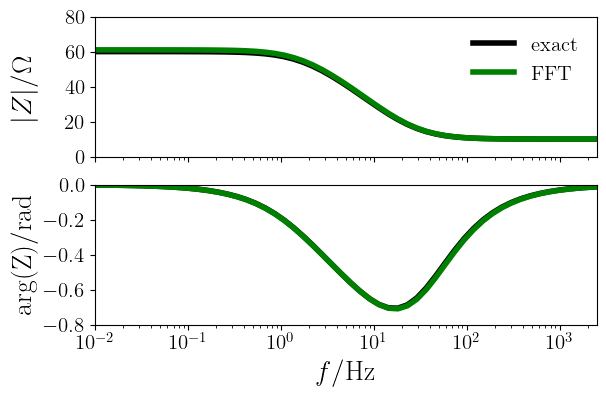

In [13]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.semilogx(freq_log, np.abs(Z_exact_log), linewidth=4, color='black', label='exact')
ax1.semilogx(freq_log, np.abs(Z_log_fft), linewidth=4, color='green', label='FFT')
ax1.set_ylabel(r'$|Z|/\mathrm{\Omega}$', fontsize = 20)
ax1.set_xlim(np.min(freq_log), np.max(freq_log))
ax1.set_ylim(0, 80)
ax1.set_yticks(np.arange(0, 80.1, step=20)) 
ax1.legend(frameon=False, fontsize = 15)

ax2.semilogx(freq_log, np.angle(Z_exact_log), linewidth=4, color='black', label='exact')
ax2.semilogx(freq_log, np.angle(Z_log_fft), linewidth=4, color='green', label='FFT')
ax2.set_ylabel(r'$\rm arg(Z)/\rm rad$', fontsize = 20)
ax2.set_ylim(-0.8, 0.0)
ax2.set_yticks(np.arange(-0.8, 0.01, 0.2))

plt.xlabel(r'$f/{\rm Hz}$', fontsize = 20)
fig.align_ylabels()
fig.set_size_inches(6.472, 4)
plt.show()